In [1]:
import numpy as np
import matplotlib.pyplot as plt
from usrp_benchmark import USRPClient

In [2]:
USRPClient.setup(
    host="localhost",
    port=8080,
    token="rsahleanu-owngmjly3727gr623metsg2s",
)

print("Server OK:", USRPClient.check())

Server OK: True


In [3]:
info = USRPClient.info()

print(f"Sample Rate:    {info['sample_rate_hz'] / 1e6:.2f} MHz")
print(f"Bandwidth:      {info['bandwidth_hz'] / 1e6:.2f} MHz")
print(f"Carrier Freq:   {info['carrier_frequency_hz'] / 1e9:.2f} GHz")
print(f"TX Gain:        {info['tx_gain_db']} dB")
print(f"RX Gain:        {info['rx_gain_db']} dB")
print(f"Max Samples:    {info['max_samples']:,}")
print(f"Real USRP:      {info['use_real_usrp']}")
print(f"Duty Cycle:     {info['duty_cycle_max_percent']}% / {info['duty_cycle_window_sec']}s")
print(f"LBT:            {info['lbt_enabled']} (threshold {info['lbt_threshold_dbfs']} dBFS)")

Sample Rate:    25.00 MHz
Bandwidth:      25.00 MHz
Carrier Freq:   2.40 GHz
TX Gain:        30.0 dB
RX Gain:        30.0 dB
Max Samples:    2,500,000
Real USRP:      True
Duty Cycle:     10.0% / 60.0s
LBT:            True (threshold -50.0 dBFS)


In [4]:
fs = info['sample_rate_hz']
n_samples = 100_000
tone_freq = 1e6  # 1 MHz offset

t = np.arange(n_samples) / fs
tx_signal = np.exp(1j * 2 * np.pi * tone_freq * t).astype(np.complex64)

print(f"TX: {n_samples:,} samples, Dauer: {n_samples/fs*1000:.2f} ms")

TX: 100,000 samples, Dauer: 4.00 ms


In [5]:
def plot_signal(signal, fs, title="Signal", n_time=500):
    signal = np.asarray(signal)
    n = len(signal)
    t = np.arange(n) / fs

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title)

    # Zeitbereich
    n_show = min(n_time, n)
    axes[0].plot(t[:n_show] * 1e6, signal[:n_show].real, label="I")
    axes[0].plot(t[:n_show] * 1e6, signal[:n_show].imag, label="Q", linestyle="--")
    axes[0].set_xlabel("Zeit [µs]")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Zeitbereich ({n_show} Samples)")
    axes[0].legend()
    axes[0].grid(True)

    # I/Q-Ebene
    axes[1].plot(signal[:n_show].real, signal[:n_show].imag, linewidth=0.8)
    axes[1].set_xlabel("I")
    axes[1].set_ylabel("Q")
    axes[1].set_title("Komplexe Ebene")
    axes[1].axis("equal")
    axes[1].grid(True)

    # Spektrum
    spectrum = np.fft.fftshift(np.fft.fft(signal))
    freqs = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    axes[2].plot(freqs / 1e6, 20 * np.log10(np.abs(spectrum) + 1e-12))
    axes[2].set_xlabel("Frequenz [MHz]")
    axes[2].set_ylabel("Magnitude [dB]")
    axes[2].set_title("Spektrum")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

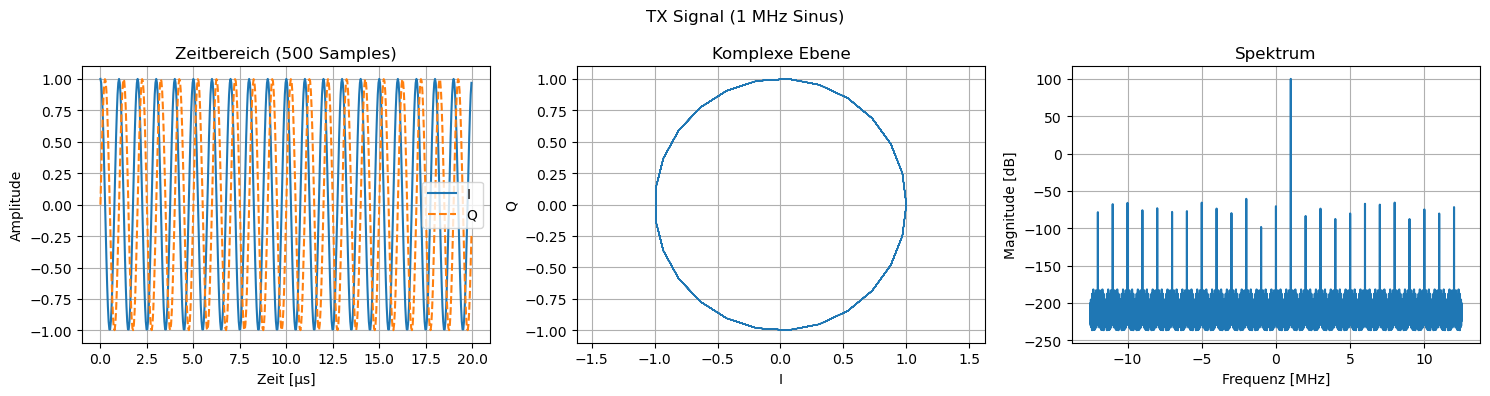

In [6]:
plot_signal(tx_signal, fs, title="TX Signal (1 MHz Sinus)")

In [24]:
rx_signal = USRPClient.send(tx_signal, verbose=True)

print(f"\nTX: {len(tx_signal):,} Samples")
print(f"RX: {len(rx_signal):,} Samples")

tx_power_db = 10 * np.log10(np.mean(np.abs(tx_signal) ** 2))
rx_power_db = 10 * np.log10(np.mean(np.abs(rx_signal) ** 2) + 1e-20)
print(f"TX Power: {tx_power_db:.1f} dB")
print(f"RX Power: {rx_power_db:.1f} dB")

[upload] Sent 800,000 bytes (100,000 samples)
[error] server_sleeping: SLEEPING ZZZZ


RuntimeError: Server error: SLEEPING ZZZZ

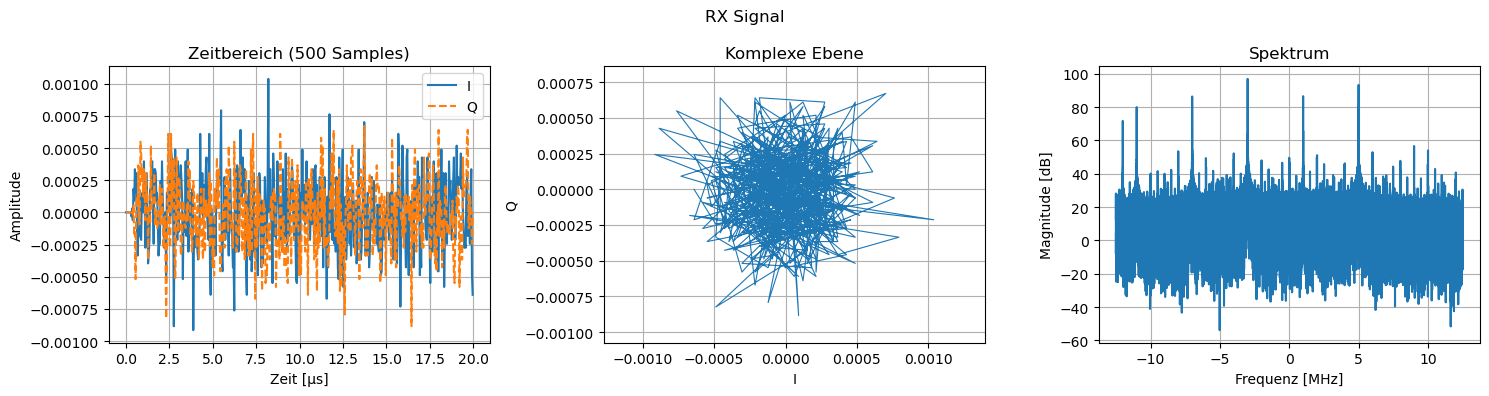

In [8]:
plot_signal(rx_signal, fs, title="RX Signal")

Kernsignal: 100,000 Samples (sollte = 100,000)


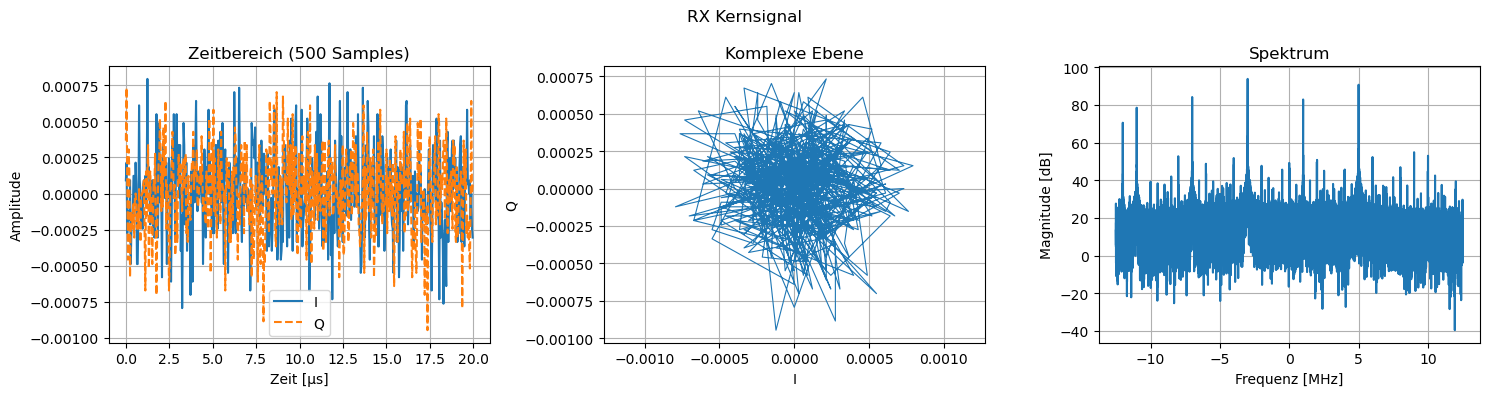

In [9]:
# Guard entspricht TX_RX_DELAY_DIFF aus der .env (default 0.1s)
guard_s = 0.1
guard_samples = int(guard_s * fs)

rx_core = rx_signal[guard_samples : guard_samples + len(tx_signal)]
print(f"Kernsignal: {len(rx_core):,} Samples (sollte = {len(tx_signal):,})")

plot_signal(rx_core, fs, title="RX Kernsignal")